In [1]:
from src.counterfactual_fraud_model.pipeline import OffPolicyEvaluationPipeline
from simulation_analysis import *

In [2]:
def run_simulations(exploration_rates: np.ndarray, 
                    cutoff: float = 0.1,
                    random_state: int = 42) -> tuple[List[Dict[str, Any]], pd.DataFrame]:
    """
    Run multiple OffPolicyEvaluationPipeline simulations with different exploration rates.
    
    Args:
        exploration_rates: Array of exploration rate values to test
        cutoff: Fixed cutoff value for all simulations
        random_state: Random seed for reproducibility
        
    Returns:
        Tuple of (list of simulation results, reference data for plots)
    """
    print(f"Running {len(exploration_rates)} simulations...")
    
    # Initialize pipeline with fixed parameters
    pipeline = OffPolicyEvaluationPipeline(
        random_state=random_state,
        ## HACK PARAMETERS ADJUSTMENT
        # beta dist for model scores
        alpha=0.1,
        beta_param=2,
        # normal dist to model model errors into real fraud probabilities
        mean=-0.5,
        sd=0.5,
        sample_size=100_000,
        # n_bootstrap=5000,
    )
    
    # Get reference data (same for all simulations since we use same data generation params)
    reference_data = pipeline.generated_data
    
    results = []
    
    for i, exploration_rate in enumerate(exploration_rates):
        print(f"Running simulation {i+1}/{len(exploration_rates)} with exploration_rate={exploration_rate:.3f}")
        
        # Run pipeline with current exploration rate
        result = pipeline.run_pipeline(
            cutoff=cutoff,
            exploration_rate=exploration_rate,
            include_data=False  # Don't include data to save memory
        )
        
        # Add exploration_rate to result for easy tracking
        result['parameters']['exploration_rate'] = exploration_rate
        results.append(result)
    
    return results, reference_data

In [3]:
exploration_rates = np.linspace(0.01, 0.1, 10)
random_state = 667

# Run simulations
results, reference_data = run_simulations(exploration_rates, random_state=random_state)

Running 10 simulations...
Running simulation 1/10 with exploration_rate=0.010
Running simulation 2/10 with exploration_rate=0.020
Running simulation 3/10 with exploration_rate=0.030
Running simulation 4/10 with exploration_rate=0.040
Running simulation 5/10 with exploration_rate=0.050
Running simulation 6/10 with exploration_rate=0.060
Running simulation 7/10 with exploration_rate=0.070
Running simulation 8/10 with exploration_rate=0.080
Running simulation 9/10 with exploration_rate=0.090
Running simulation 10/10 with exploration_rate=0.100


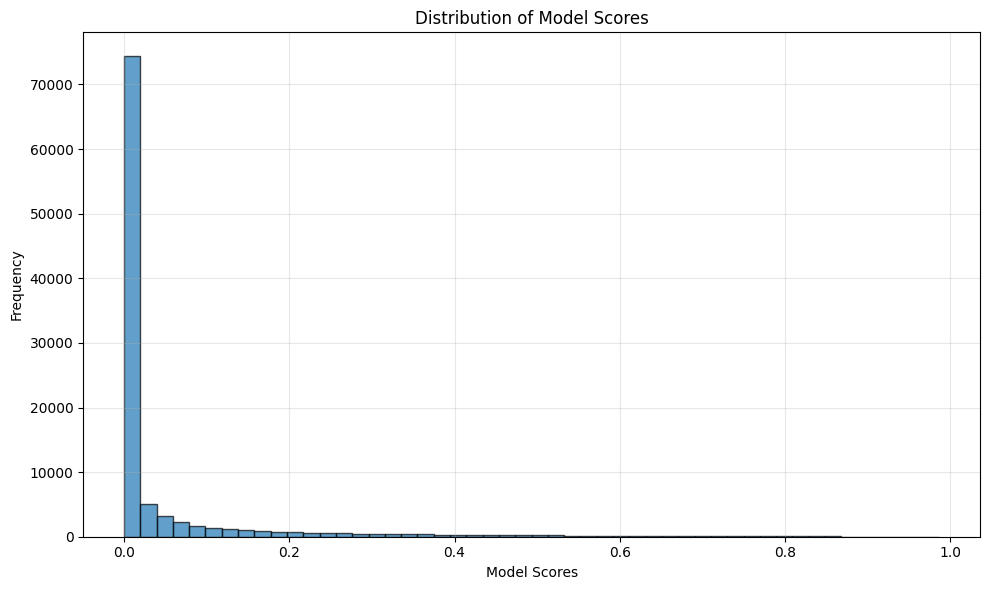

In [4]:
plot_model_scores_histogram(reference_data)

In [5]:
pipeline_params = results[0]['parameters']
summary_table = create_data_summary_table(reference_data, pipeline_params)
summary_table

,Metric,Value
0,Total Transactions,100000
1,True Fraud Rate,0.0533
2,Alpha,0.1
3,Beta,2
4,Mean,-0.5
5,SD,0.5
6,Sample Size,100000


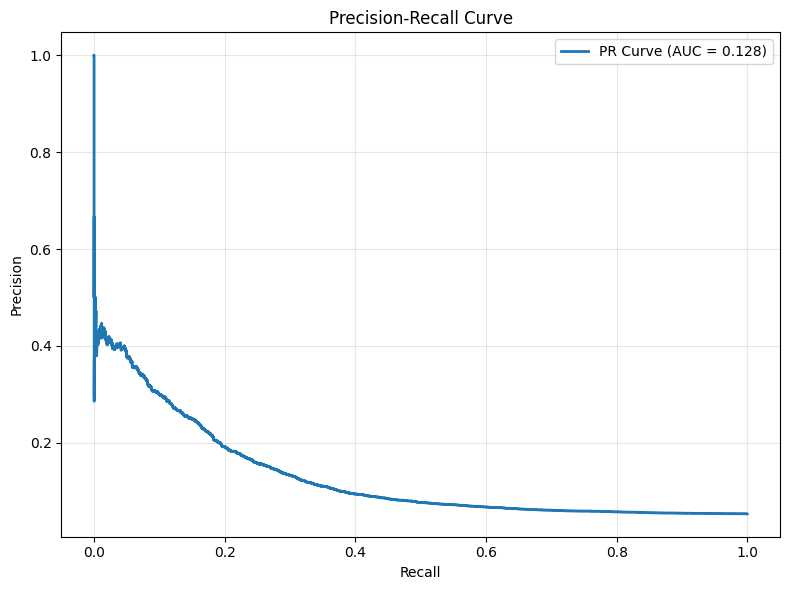

In [6]:
plot_precision_recall_curve(reference_data)

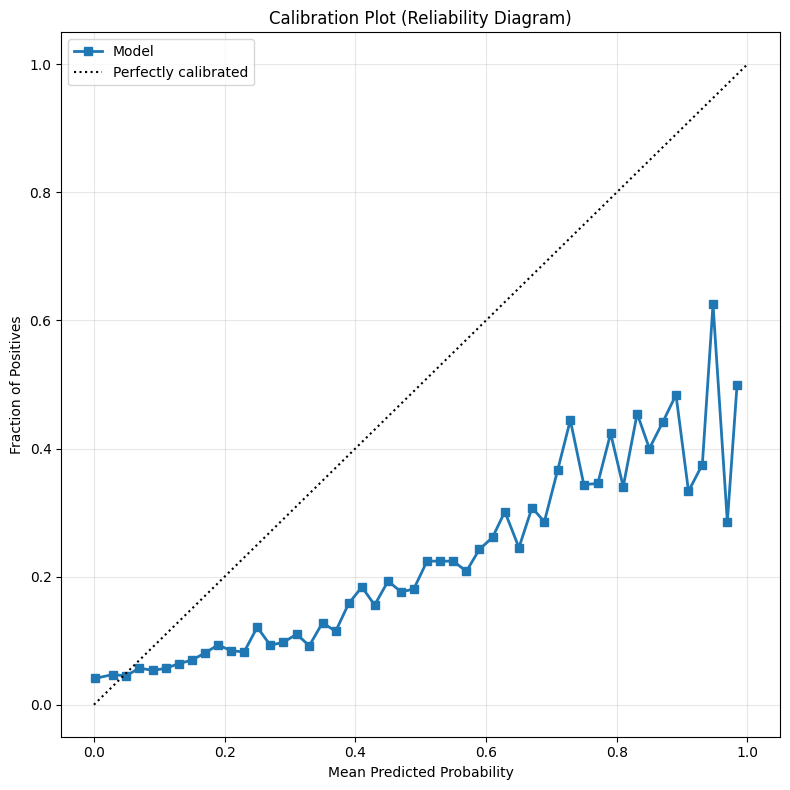

In [7]:
plot_calibration_curve(reference_data)

In [8]:
policy_table = create_policy_metrics_table(results)
policy_table

,exploration_rate,policy_approval_rate,policy_fraud_rate,approval_rate_increase,fraud_rate_increase
0,0.01,0.86857,0.042484,0.001360,0.005179
1,0.02,0.87001,0.042563,0.003021,0.007051
2,0.03,0.87135,0.042635,0.004565,0.008761
3,0.04,0.87260,0.042815,0.006007,0.013010
4,0.05,0.87407,0.042971,0.007701,0.016720
5,0.06,0.87537,0.042999,0.009200,0.017372
6,0.07,0.87666,0.043084,0.010687,0.019384
7,0.08,0.87792,0.043330,0.012140,0.025197
8,0.09,0.87923,0.043424,0.013650,0.027437
9,0.10,0.88045,0.043535,0.015057,0.030045


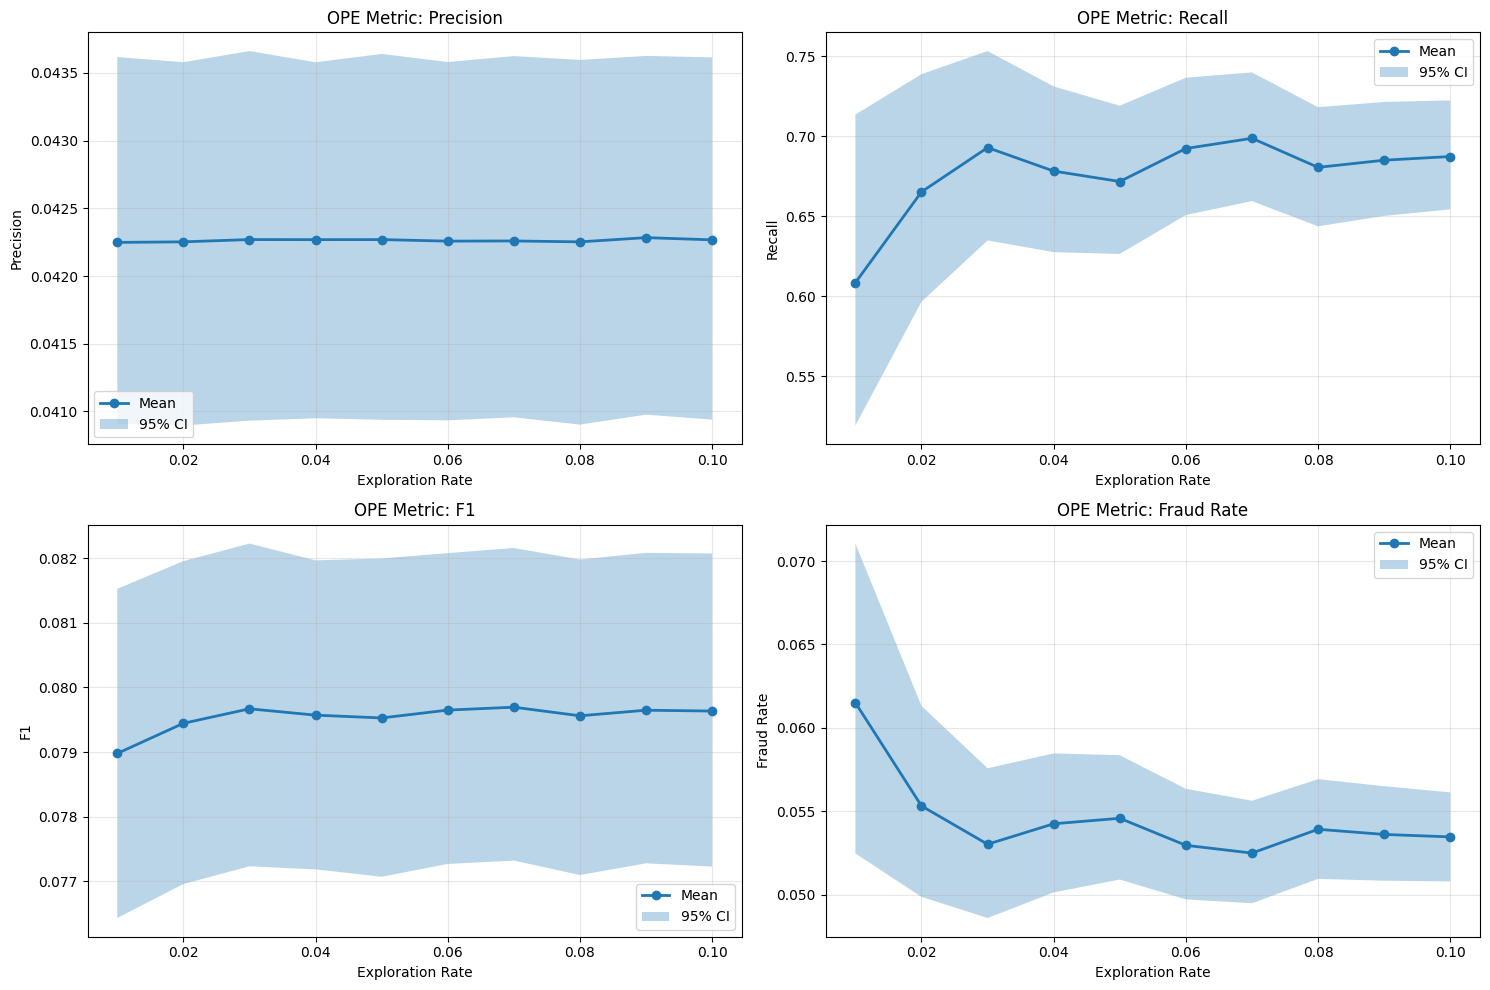

In [9]:
plot_ope_metrics(results)

In [10]:
from synthetic_simulation_analysis import *

Starting Synthetic Multi-Parameter Simulation Analysis

Exploration Rate Analysis with lightgbm model
Running 3 simulations with lightgbm model...


/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Running simulation 1/3 with exploration_rate=0.010


/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Running simulation 2/3 with exploration_rate=0.055


/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Running simulation 3/3 with exploration_rate=0.100

Generating visualizations and tables...
1. Generating model scores histogram...


/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


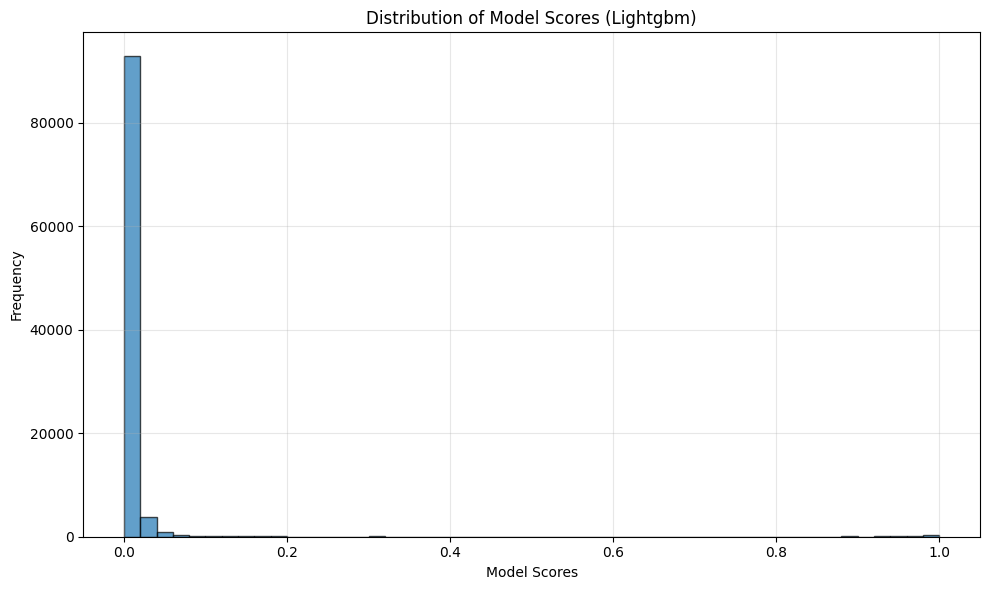

2. Creating data summary table...

Synthetic Data Summary Table:
            Metric    Value
Total Transactions   100000
   True Fraud Rate   0.0198
         N Samples   100000
        N Features       30
     N Informative       15
       N Redundant        5
        Model Type lightgbm
         Test Size      0.3
         Class Sep      1.0

3. Generating calibration plot...


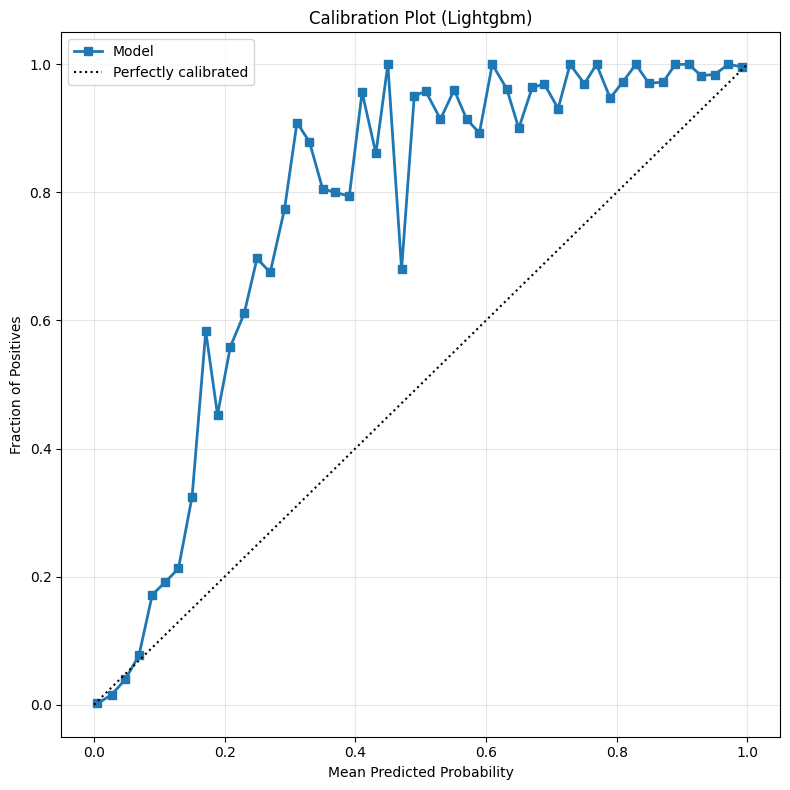

4. Generating precision-recall curve...


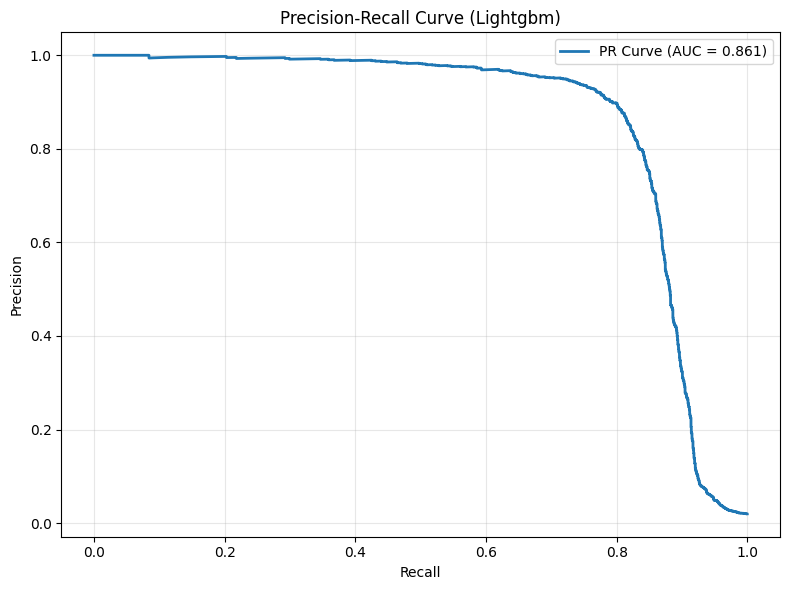

5. Creating policy metrics table...

Policy Metrics Table:
 exploration_rate  policy_approval_rate  policy_fraud_rate  approval_rate_increase  fraud_rate_increase  model_roc_auc  model_precision  model_recall  model_f1
            0.010                0.9711             0.0028                  0.0003               0.0462         0.8533           0.9153         0.363    0.5199
            0.055                0.9725             0.0036                  0.0017               0.3658         0.8533           0.9153         0.363    0.5199
            0.100                0.9740             0.0045                  0.0032               0.7115         0.8533           0.9153         0.363    0.5199

6. Generating OPE metrics plots...


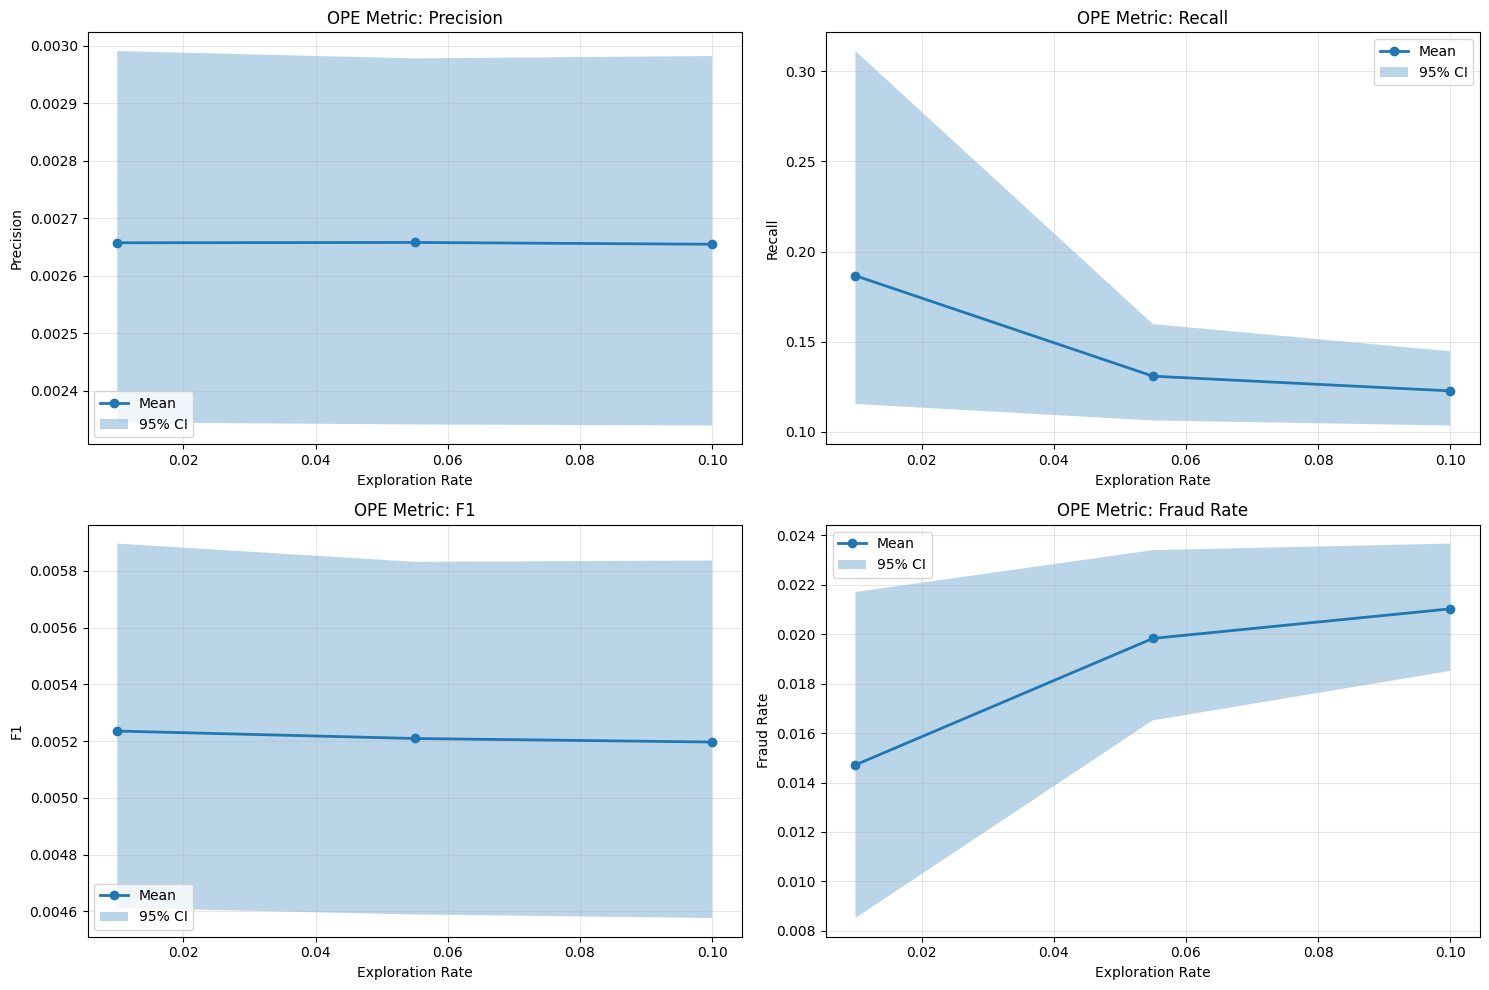


Model Comparison Analysis
Running model comparison with 2 models...
Running simulation 1/2 with lightgbm model...


/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rbrosa/Documents/github_personal/counterfactual-fraud-model/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Running simulation 2/2 with random_forest model...

Generating visualizations and tables...
1. Generating model scores comparison...


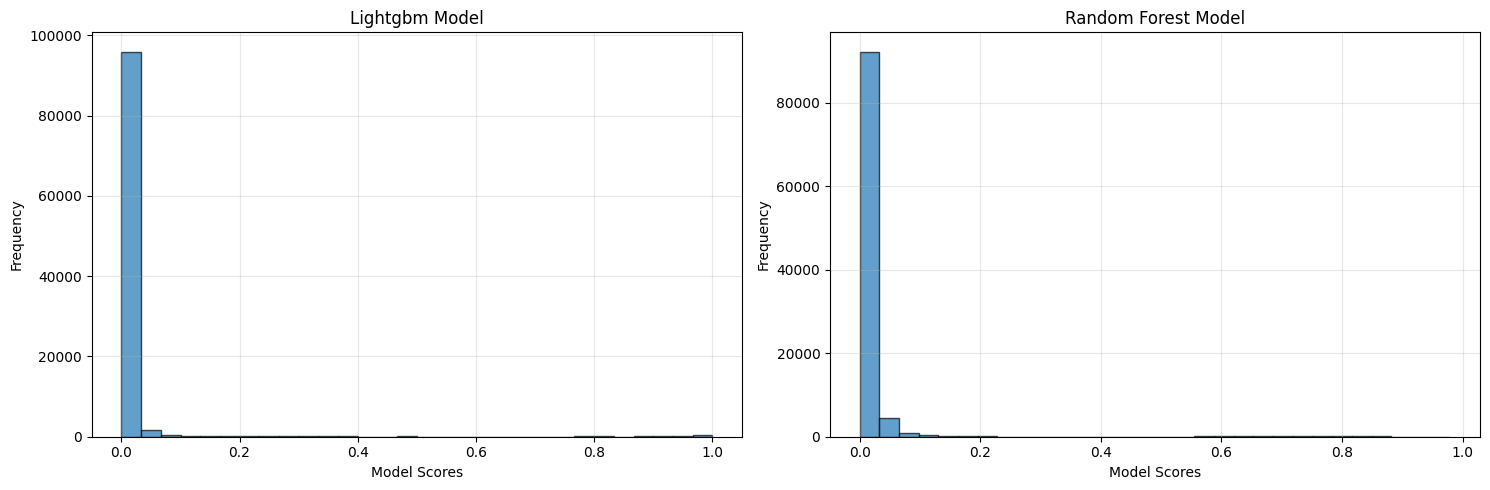

2. Creating model comparison table...

Model Comparison Table:
   model_type  policy_approval_rate  policy_fraud_rate  approval_rate_increase  fraud_rate_increase  model_roc_auc  model_precision  model_recall  model_f1
     lightgbm                0.9724             0.0035                  0.0016               0.3273         0.8533           0.9153        0.3630    0.5199
random_forest                0.9606             0.0029                  0.0022               0.5736         0.8513           1.0000        0.1597    0.2754

3. Generating model performance comparison...


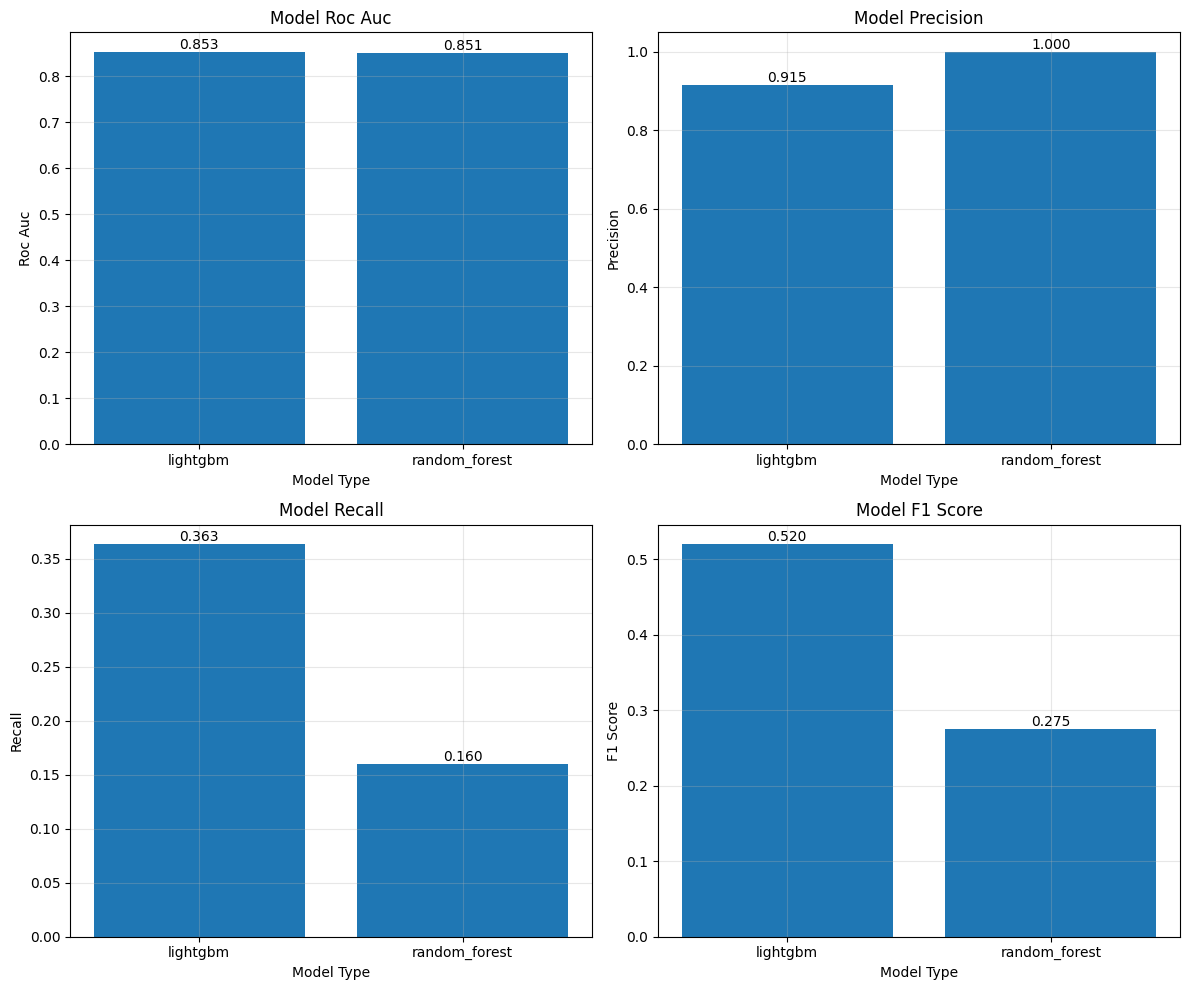

4. Generating calibration plots for each model...


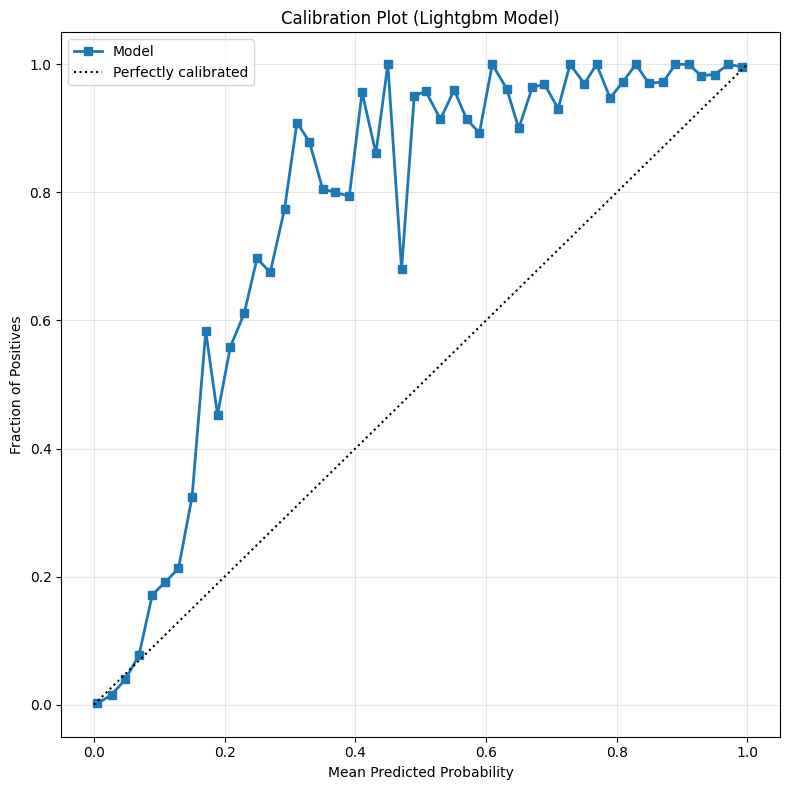

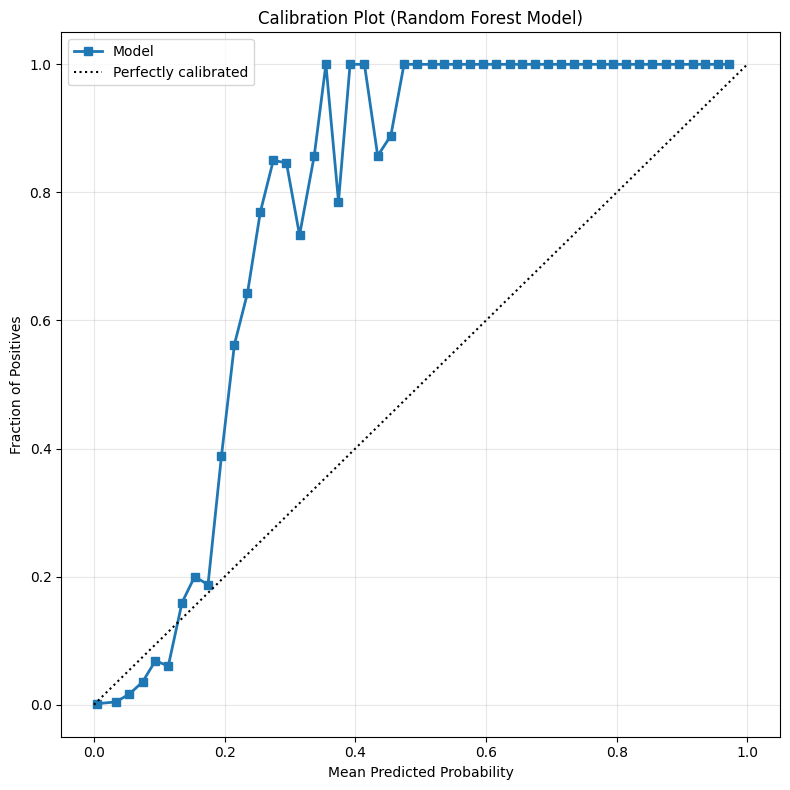

5. Generating precision-recall curves for each model...


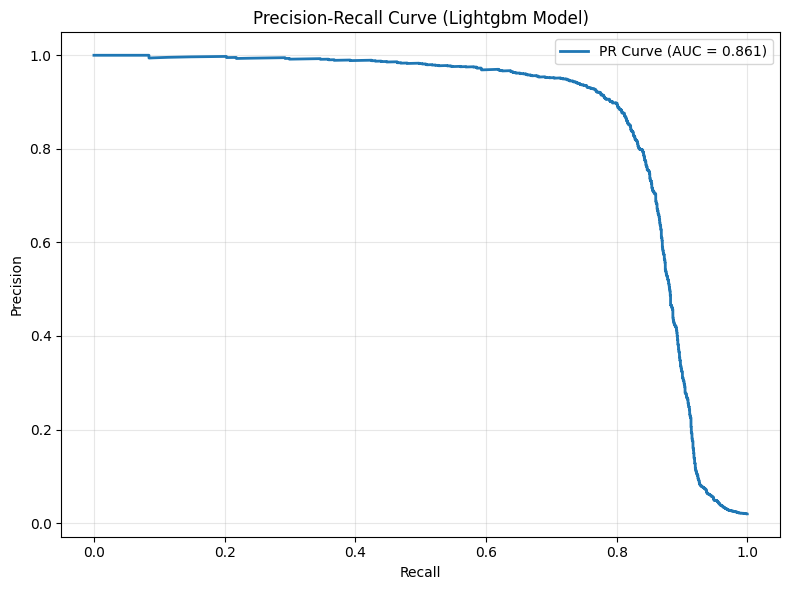

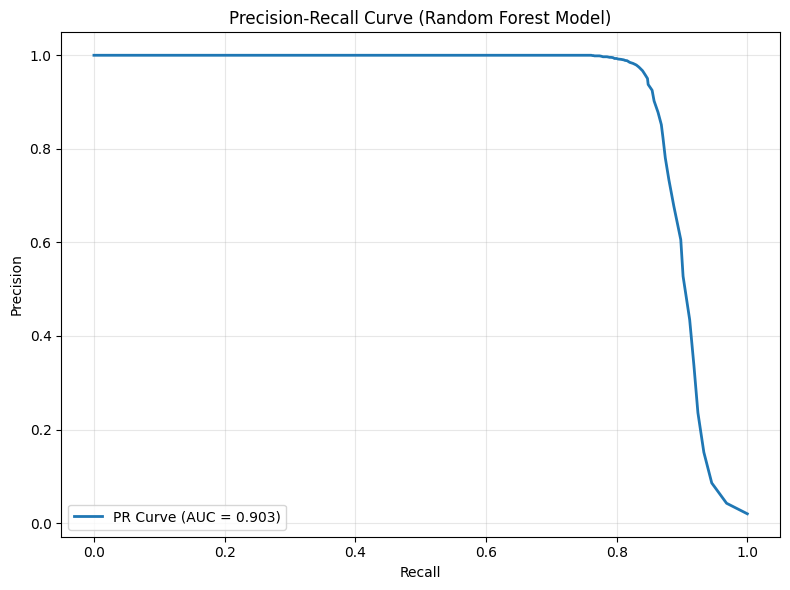


All analyses complete!


In [11]:
print("Starting Synthetic Multi-Parameter Simulation Analysis")
print("=" * 60)

# Configuration for exploration rate analysis
exploration_rates = np.linspace(0.01, 0.1, 3)

# Configuration for model comparison
model_types = ["lightgbm", "random_forest"]

# Run exploration rate analysis with LightGBM
run_exploration_rate_analysis(exploration_rates, model_type="lightgbm")

# Run model comparison analysis
run_model_comparison_analysis(model_types)

print("\nAll analyses complete!")
print("=" * 60)